In [1]:
!pip install -q pandas
!pip install -q matplotlib
!pip install -q seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../data/data_part1.csv")

In [3]:
def get_quantplot(series):
    quantiles = np.arange(0, 1.00, 0.01)
    q_values = series.quantile(quantiles)
    
    plt.figure(figsize=(10, 6))
    q_values.plot(kind='line', linewidth=2, marker='o', markersize=3)
    plt.title('График возрастания квантилей цены')
    plt.xlabel('Квантиль (0-1)')
    plt.ylabel('Значение')
    plt.grid(True, alpha=0.3)
    plt.show()


In [4]:
data.head()

,Название,Цена,Дата,Телефон,Оператор,Контактное лицо (автор объявления),Тип автора,Регион,Город,Метро/Район,...,Источник,lat,lng,Персона для контактов,Доп.параметры,URL,Ссылки на картинки,Регион мобильного телефона,Номер подменён,"Расстояние до метро, км"
0,"Склад в Московская область, Домодедово Белые С...",14036400,2025-12-17 08:36:41,89160868835,Мобильные ТелеСистемы,Складской отдел (Praedium),Агентство,Московская область,Домодедово,Домодедовская,...,cian.ru,55.334788,37.816459,NaN,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/320133256,https://images.cdn-cian.ru/images/2573972031-1...,г. Москва и Московская область,да,29.333
1,"Склад в Московская область, Пушкино Ярославско...",11160000,2025-12-17 08:36:41,89160868835,Мобильные ТелеСистемы,Складской отдел (Praedium),Агентство,Московская область,Пушкино,NaN,...,cian.ru,56.037046,37.873422,NaN,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322219290,https://images.cdn-cian.ru/images/2643669173-1...,г. Москва и Московская область,да,неизвестно
2,"Склад в Московская область, Домодедово Белые С...",17908800,2025-12-17 08:36:41,89160868835,Мобильные ТелеСистемы,Складской отдел (Praedium),Агентство,Московская область,Домодедово,Домодедовская,...,cian.ru,55.334788,37.816459,NaN,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/323692494,https://images.cdn-cian.ru/images/2693030518-1...,г. Москва и Московская область,да,29.333
3,"Склад в Московская область, Чехов муниципальны...",1344000,2025-12-17 08:36:41,89160868835,Мобильные ТелеСистемы,Складской отдел (Praedium),Агентство,Московская область,Чехов муниципальный округ,NaN,...,cian.ru,55.133606,37.591126,NaN,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322765646,https://images.cdn-cian.ru/images/2661922554-1...,г. Москва и Московская область,да,неизвестно
4,"Склад в Московская область, Клин Волоколамское...",35910000,2025-12-17 08:36:41,89160868835,Мобильные ТелеСистемы,Складской отдел (Praedium),Агентство,Московская область,Клин,NaN,...,cian.ru,56.331204,36.678842,NaN,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322861972,https://images.cdn-cian.ru/images/2665198761-1...,г. Москва и Московская область,да,неизвестно


In [5]:
data.isna().sum()

Название                                  0
Цена                                      0
Дата                                      0
Телефон                                   0
Оператор                                  0
Контактное лицо (автор объявления)      107
Тип автора                                0
Регион                                    0
Город                                     0
Метро/Район                            6909
Адрес                                  3627
Описание                                306
Тип объявления                            0
Категория1                                0
Категория2                                0
ID на сайте                               0
Источник                                  0
lat                                       0
lng                                       0
Персона для контактов                 20000
Доп.параметры                             0
URL                                       0
Ссылки на картинки              

In [6]:
data = data.dropna(subset=["Цена"])

In [7]:
data.columns

Index(['Название', 'Цена', 'Дата', 'Телефон', 'Оператор',
       'Контактное лицо (автор объявления)', 'Тип автора', 'Регион', 'Город',
       'Метро/Район', 'Адрес', 'Описание', 'Тип объявления', 'Категория1',
       'Категория2', 'ID на сайте', 'Источник', 'lat', 'lng',
       'Персона для контактов', 'Доп.параметры', 'URL', 'Ссылки на картинки',
       'Регион мобильного телефона', 'Номер подменён',
       'Расстояние до метро, км'],
      dtype='object')

In [8]:
data = data.drop([
    'Телефон', 'Оператор', 'Контактное лицо (автор объявления)',
    'Персона для контактов', 'Регион мобильного телефона', 'Номер подменён',
    'Тип объявления', 'Категория1', 'Категория2'
], axis = 1)

In [9]:
data.columns

Index(['Название', 'Цена', 'Дата', 'Тип автора', 'Регион', 'Город',
       'Метро/Район', 'Адрес', 'Описание', 'ID на сайте', 'Источник', 'lat',
       'lng', 'Доп.параметры', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км'],
      dtype='object')

In [10]:
data = data.set_index(['ID на сайте', 'Источник',])

In [11]:
data.head()

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,Доп.параметры,URL,Ссылки на картинки,"Расстояние до метро, км"
ID на сайте,Источник,,,,,,,,,,,,,,,
320133256,cian.ru,"Склад в Московская область, Домодедово Белые С...",14036400,2025-12-17 08:36:41,Агентство,Московская область,Домодедово,Домодедовская,"Белые Столбы мкр, ул. Лермонтова, 3",ID: w13575 В аренду предлагается теплый склад ...,55.334788,37.816459,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/320133256,https://images.cdn-cian.ru/images/2573972031-1...,29.333
322219290,cian.ru,"Склад в Московская область, Пушкино Ярославско...",11160000,2025-12-17 08:36:41,Агентство,Московская область,Пушкино,NaN,"Ярославское ш., 228",ID: w13713 В производственно-складском комплек...,56.037046,37.873422,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322219290,https://images.cdn-cian.ru/images/2643669173-1...,неизвестно
323692494,cian.ru,"Склад в Московская область, Домодедово Белые С...",17908800,2025-12-17 08:36:41,Агентство,Московская область,Домодедово,Домодедовская,"Белые Столбы мкр, ул. Лермонтова, 3",ID: w11209 Предлагается в аренду склад класса ...,55.334788,37.816459,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/323692494,https://images.cdn-cian.ru/images/2693030518-1...,29.333
322765646,cian.ru,"Склад в Московская область, Чехов муниципальны...",1344000,2025-12-17 08:36:41,Агентство,Московская область,Чехов муниципальный округ,NaN,11,ID: w13834 В аренду предлагается холодный скла...,55.133606,37.591126,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322765646,https://images.cdn-cian.ru/images/2661922554-1...,неизвестно
322861972,cian.ru,"Склад в Московская область, Клин Волоколамское...",35910000,2025-12-17 08:36:41,Агентство,Московская область,Клин,NaN,"Волоколамское ш., 4",ID: w13840 В аренду предлагается склад класса ...,56.331204,36.678842,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322861972,https://images.cdn-cian.ru/images/2665198761-1...,неизвестно


In [12]:
data.loc[(320133256, 'cian.ru')]

Название                   Склад в Московская область, Домодедово Белые С...
Цена                                                                14036400
Дата                                                     2025-12-17 08:36:41
Тип автора                                                         Агентство
Регион                                                    Московская область
Город                                                             Домодедово
Метро/Район                                                    Домодедовская
Адрес                                    Белые Столбы мкр, ул. Лермонтова, 3
Описание                   ID: w13575 В аренду предлагается теплый склад ...
lat                                                                55.334788
lng                                                                37.816459
Доп.параметры              Этаж=1|Этажность здания=1|Тип объявления=Сдам|...
URL                            https://www.cian.ru/rent/commercial/320133256

In [13]:
data["Описание"] = "НАЗВАНИЕ: " + data["Название"] + "\n\nОПИСАНИЕ: " + data["Описание"]

In [14]:
data.loc[(320133256, "cian.ru"), ("Название", "Описание")]

Название    Склад в Московская область, Домодедово Белые С...
Описание    НАЗВАНИЕ: Склад в Московская область, Домодедо...
Name: (320133256, cian.ru), dtype: object

In [15]:
data

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,Доп.параметры,URL,Ссылки на картинки,"Расстояние до метро, км"
ID на сайте,Источник,,,,,,,,,,,,,,,
320133256,cian.ru,"Склад в Московская область, Домодедово Белые С...",14036400,2025-12-17 08:36:41,Агентство,Московская область,Домодедово,Домодедовская,"Белые Столбы мкр, ул. Лермонтова, 3","НАЗВАНИЕ: Склад в Московская область, Домодедо...",55.334788,37.816459,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/320133256,https://images.cdn-cian.ru/images/2573972031-1...,29.333
322219290,cian.ru,"Склад в Московская область, Пушкино Ярославско...",11160000,2025-12-17 08:36:41,Агентство,Московская область,Пушкино,NaN,"Ярославское ш., 228","НАЗВАНИЕ: Склад в Московская область, Пушкино ...",56.037046,37.873422,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322219290,https://images.cdn-cian.ru/images/2643669173-1...,неизвестно
323692494,cian.ru,"Склад в Московская область, Домодедово Белые С...",17908800,2025-12-17 08:36:41,Агентство,Московская область,Домодедово,Домодедовская,"Белые Столбы мкр, ул. Лермонтова, 3","НАЗВАНИЕ: Склад в Московская область, Домодедо...",55.334788,37.816459,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/323692494,https://images.cdn-cian.ru/images/2693030518-1...,29.333
322765646,cian.ru,"Склад в Московская область, Чехов муниципальны...",1344000,2025-12-17 08:36:41,Агентство,Московская область,Чехов муниципальный округ,NaN,11,"НАЗВАНИЕ: Склад в Московская область, Чехов му...",55.133606,37.591126,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322765646,https://images.cdn-cian.ru/images/2661922554-1...,неизвестно
322861972,cian.ru,"Склад в Московская область, Клин Волоколамское...",35910000,2025-12-17 08:36:41,Агентство,Московская область,Клин,NaN,"Волоколамское ш., 4","НАЗВАНИЕ: Склад в Московская область, Клин Вол...",56.331204,36.678842,Этаж=1|Этажность здания=1|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/322861972,https://images.cdn-cian.ru/images/2665198761-1...,неизвестно
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320879786,cian.ru,"Торговая площадь в Московская область, Красног...",250000,2025-10-19 22:29:12,Агентство,Московская область,Красногорск,Липовая Роща,"ул. Тенистых Аллей, 1к2",НАЗВАНИЕ: Торговая площадь в Московская област...,55.800580,37.377587,Этаж=1|Этажность здания=31|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/320879786,https://images.cdn-cian.ru/images/2597374036-1...,1
322077443,cian.ru,Помещение свободного назначения в Московская о...,207000,2025-10-19 22:29:12,Агентство,Московская область,Балашиха,Щёлковская,"ул. Чистопольская, 32",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.843106,37.977258,Этаж=1|Этажность здания=21|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/322077443,https://images.cdn-cian.ru/images/2660957824-1...,17.417
317894637,cian.ru,Помещение свободного назначения в Московская о...,191106,2025-10-19 22:29:11,Частное лицо (фильтр),Московская область,Ленинский городской округ,Домодедовская,к18,НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.555952,37.830213,Этаж=1|Этажность здания=17|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/317894637,https://images.cdn-cian.ru/images/2499076452-1...,14.667


In [16]:
data = data.drop("Название", axis=1)

In [17]:
data["Доп.параметры"].iloc[10]

'Этаж=1|Этажность здания=1|Тип объявления=Сдам|Вид объекта=Складское помещение|Общая площадь=550'

In [18]:
def parse_parameners(v):
    return dict(pair.split("=") for pair in v.split('|'))
parse_parameners(data["Доп.параметры"].iloc[10])

{'Этаж': '1',
 'Этажность здания': '1',
 'Тип объявления': 'Сдам',
 'Вид объекта': 'Складское помещение',
 'Общая площадь': '550'}

In [19]:
_ = data["Доп.параметры"].apply(parse_parameners)
params_parsed = pd.json_normalize(_)
params_parsed.index = data.index

In [20]:
params_parsed.isna().sum() / params_parsed.shape[0] * 100

Этаж                     19.985
Этажность здания         18.160
Тип объявления            0.000
Вид объекта               0.000
Общая площадь             0.000
Ед. измерения площади    82.070
Категория                82.860
dtype: float64

In [21]:
params_parsed.nunique()

Этаж                       31
Этажность здания           42
Тип объявления              1
Вид объекта                 8
Общая площадь            3776
Ед. измерения площади       2
Категория                   3
dtype: int64

In [22]:
params_parsed = params_parsed.drop(["Тип объявления"], axis=1)

In [23]:
data = pd.concat(
    [
        data.drop(["Доп.параметры"], axis=1),
        params_parsed
    ],
    axis=1
)

In [24]:
data.dtypes

Цена                         int64
Дата                        object
Тип автора                  object
Регион                      object
Город                       object
Метро/Район                 object
Адрес                       object
Описание                    object
lat                        float64
lng                        float64
URL                         object
Ссылки на картинки          object
Расстояние до метро, км     object
Этаж                        object
Этажность здания            object
Вид объекта                 object
Общая площадь               object
Ед. измерения площади       object
Категория                   object
dtype: object

In [25]:
data["Дата"] = pd.to_datetime(data["Дата"])
data["Дата"]

ID на сайте  Источник
320133256    cian.ru    2025-12-17 08:36:41
322219290    cian.ru    2025-12-17 08:36:41
323692494    cian.ru    2025-12-17 08:36:41
322765646    cian.ru    2025-12-17 08:36:41
322861972    cian.ru    2025-12-17 08:36:41
                                ...        
320879786    cian.ru    2025-10-19 22:29:12
322077443    cian.ru    2025-10-19 22:29:12
317894637    cian.ru    2025-10-19 22:29:11
318349332    cian.ru    2025-10-19 22:29:11
321229527    cian.ru    2025-10-19 22:29:04
Name: Дата, Length: 20000, dtype: datetime64[ns]

In [26]:
data["Расстояние до метро, км"] = data["Расстояние до метро, км"].replace({"неизвестно": np.nan})
data [[
    "Расстояние до метро, км",
    "Этаж",
    "Этажность здания",
    "Общая площадь", "Цена"
]] = data [[
    "Расстояние до метро, км",
    "Этаж",
    "Этажность здания",
    "Общая площадь", "Цена"
]].astype(float)

In [27]:
data.isna().sum()

Цена                           0
Дата                           0
Тип автора                     0
Регион                         0
Город                          0
Метро/Район                 6909
Адрес                       3627
Описание                     306
lat                            0
lng                            0
URL                            0
Ссылки на картинки           388
Расстояние до метро, км     7355
Этаж                        3997
Этажность здания            3632
Вид объекта                    0
Общая площадь                  0
Ед. измерения площади      16414
Категория                  16572
dtype: int64

In [28]:
data[["Общая площадь", "Ед. измерения площади"]].dropna()

,,Общая площадь,Ед. измерения площади
ID на сайте,Источник,,
324247679,cian.ru,14.97,сот.
324247677,cian.ru,24.00,сот.
324185651,cian.ru,33.25,сот.
324185873,cian.ru,10.00,сот.
324247683,cian.ru,14.33,сот.
...,...,...,...
322779895,cian.ru,11.01,сот.
318127934,cian.ru,12.00,сот.
323072784,cian.ru,20.00,сот.


In [29]:
data.loc[data["Ед. измерения площади"] == "сот.",
    "Общая площадь"] *= 100
data.loc[data["Ед. измерения площади"] == "га.",
    "Общая площадь"] *= 10000

data.loc[data["Ед. измерения площади"] == "га.",
    "Общая площадь"]

In [30]:
data = data.drop("Ед. измерения площади", axis=1)

In [31]:
data

,,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
320133256,cian.ru,14036400.0,2025-12-17 08:36:41,Агентство,Московская область,Домодедово,Домодедовская,"Белые Столбы мкр, ул. Лермонтова, 3","НАЗВАНИЕ: Склад в Московская область, Домодедо...",55.334788,37.816459,https://www.cian.ru/rent/commercial/320133256,https://images.cdn-cian.ru/images/2573972031-1...,29.333,1.0,1.0,Складское помещение,10026.0,NaN
322219290,cian.ru,11160000.0,2025-12-17 08:36:41,Агентство,Московская область,Пушкино,NaN,"Ярославское ш., 228","НАЗВАНИЕ: Склад в Московская область, Пушкино ...",56.037046,37.873422,https://www.cian.ru/rent/commercial/322219290,https://images.cdn-cian.ru/images/2643669173-1...,NaN,1.0,1.0,Складское помещение,9000.0,NaN
323692494,cian.ru,17908800.0,2025-12-17 08:36:41,Агентство,Московская область,Домодедово,Домодедовская,"Белые Столбы мкр, ул. Лермонтова, 3","НАЗВАНИЕ: Склад в Московская область, Домодедо...",55.334788,37.816459,https://www.cian.ru/rent/commercial/323692494,https://images.cdn-cian.ru/images/2693030518-1...,29.333,1.0,1.0,Складское помещение,12792.0,NaN
322765646,cian.ru,1344000.0,2025-12-17 08:36:41,Агентство,Московская область,Чехов муниципальный округ,NaN,11,"НАЗВАНИЕ: Склад в Московская область, Чехов му...",55.133606,37.591126,https://www.cian.ru/rent/commercial/322765646,https://images.cdn-cian.ru/images/2661922554-1...,NaN,1.0,1.0,Складское помещение,2240.0,NaN
322861972,cian.ru,35910000.0,2025-12-17 08:36:41,Агентство,Московская область,Клин,NaN,"Волоколамское ш., 4","НАЗВАНИЕ: Склад в Московская область, Клин Вол...",56.331204,36.678842,https://www.cian.ru/rent/commercial/322861972,https://images.cdn-cian.ru/images/2665198761-1...,NaN,1.0,1.0,Складское помещение,31500.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320879786,cian.ru,250000.0,2025-10-19 22:29:12,Агентство,Московская область,Красногорск,Липовая Роща,"ул. Тенистых Аллей, 1к2",НАЗВАНИЕ: Торговая площадь в Московская област...,55.800580,37.377587,https://www.cian.ru/rent/commercial/320879786,https://images.cdn-cian.ru/images/2597374036-1...,1.000,1.0,31.0,Торговое помещение,45.0,NaN
322077443,cian.ru,207000.0,2025-10-19 22:29:12,Агентство,Московская область,Балашиха,Щёлковская,"ул. Чистопольская, 32",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.843106,37.977258,https://www.cian.ru/rent/commercial/322077443,https://images.cdn-cian.ru/images/2660957824-1...,17.417,1.0,21.0,Помещение свободного назначения,138.0,NaN
317894637,cian.ru,191106.0,2025-10-19 22:29:11,Частное лицо (фильтр),Московская область,Ленинский городской округ,Домодедовская,к18,НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.555952,37.830213,https://www.cian.ru/rent/commercial/317894637,https://images.cdn-cian.ru/images/2499076452-1...,14.667,1.0,17.0,Помещение свободного назначения,88.0,NaN


# -------------------------------------------------------------------------------


In [32]:
data = data[data["Вид объекта"] != "Коммерческая земля"].copy()
data = data[data["Вид объекта"] != "Складское помещение"].copy()
data = data[data["Вид объекта"] != "Производственное помещение"].copy()
#data = data[data["Вид объекта"] != "Офисное помещение"].copy()
data = data[data["Вид объекта"] != "Гостиница"].copy()
#data = data[data["Вид объекта"] != "Здание"].copy()
data = data[data["Общая площадь"] <= 2000].copy()
data = data[data["Общая площадь"] >= 20].copy()

In [33]:
data2 = data.copy()
mask = (data2["Цена"] >= data2["Цена"].quantile(0.97))
data2.loc[mask, "Цена"] /= 12.0
data = data2.copy()

In [34]:
data["Вид объекта"].value_counts()

Вид объекта
Помещение свободного назначения    3507
Офисное помещение                  2145
Торговое помещение                 1043
Здание                              256
Name: count, dtype: int64

In [35]:
data["Общая площадь"].describe()

count    6951.000000
mean      344.611535
std       432.089371
min        20.000000
25%        65.000000
50%       145.000000
75%       450.000000
max      2000.000000
Name: Общая площадь, dtype: float64

In [36]:
data

,,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321155935,cian.ru,2211842.0,2025-12-17 08:36:41,Агентство,Московская область,Красногорск городской округ,Павшино,5с3,"НАЗВАНИЕ: Офис в Московская область, Красногор...",55.784465,37.241609,https://www.cian.ru/rent/commercial/321155935,https://images.cdn-cian.ru/images/2606525559-1...,11.000,3.0,8.0,Офисное помещение,1561.0,NaN
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Московская область,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офисное помещение,23.0,NaN
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Московская область,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое помещение,107.0,NaN
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Московская область,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офисное помещение,830.0,NaN
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Московская область,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офисное помещение,160.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321236182,cian.ru,220000.0,2025-10-20 00:46:46,Агентство,Московская область,Химки,Химки,"Куркинское ш., с2","НАЗВАНИЕ: Офис в Московская область, Химки Кур...",55.883439,37.434298,https://www.cian.ru/rent/commercial/321236182,https://images.cdn-cian.ru/images/2609061744-1...,1.917,4.0,29.0,Офисное помещение,100.0,NaN
320879786,cian.ru,250000.0,2025-10-19 22:29:12,Агентство,Московская область,Красногорск,Липовая Роща,"ул. Тенистых Аллей, 1к2",НАЗВАНИЕ: Торговая площадь в Московская област...,55.800580,37.377587,https://www.cian.ru/rent/commercial/320879786,https://images.cdn-cian.ru/images/2597374036-1...,1.000,1.0,31.0,Торговое помещение,45.0,NaN
322077443,cian.ru,207000.0,2025-10-19 22:29:12,Агентство,Московская область,Балашиха,Щёлковская,"ул. Чистопольская, 32",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.843106,37.977258,https://www.cian.ru/rent/commercial/322077443,https://images.cdn-cian.ru/images/2660957824-1...,17.417,1.0,21.0,Помещение свободного назначения,138.0,NaN


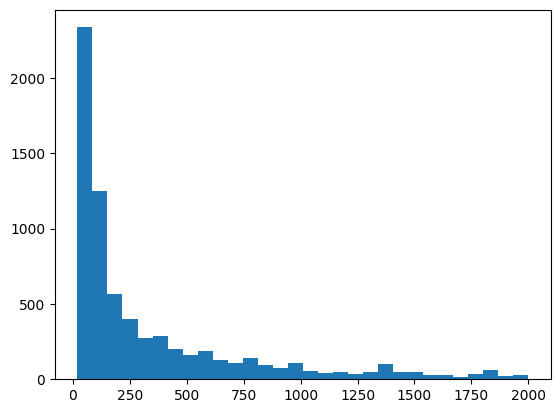

In [37]:
plt.hist(data["Общая площадь"], bins=30)
plt.show()

In [38]:
data = data[data["Цена"] <= 2000000].copy()
data = data[data["Цена"] >= 20000].copy()

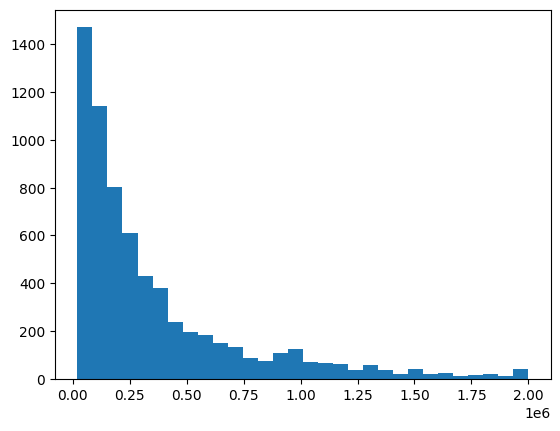

In [39]:
plt.hist(data["Цена"], bins=30)
plt.show()

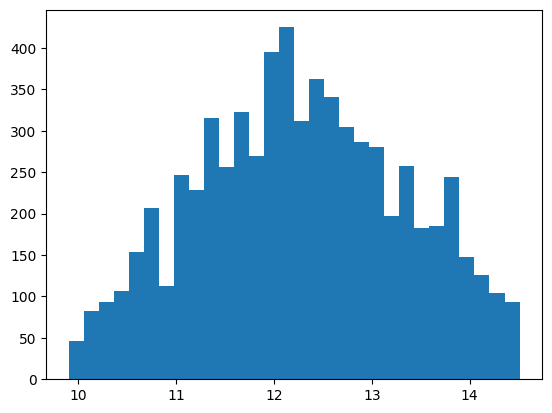

In [40]:
plt.hist(np.log1p(data["Цена"]), bins = 30)
plt.show()

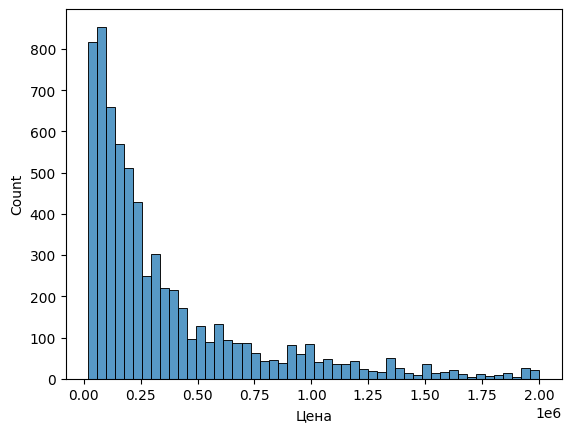

In [41]:
sns.histplot(data, x="Цена", bins=50)
plt.show()

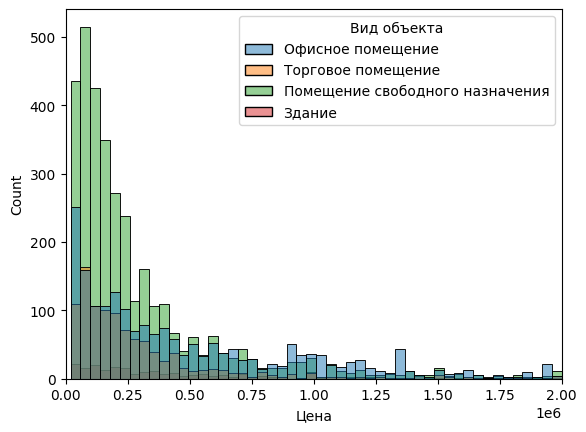

In [42]:
sns.histplot(data, x="Цена",hue="Вид объекта", bins=50)
plt.xlim([0, 2e6])
plt.show()

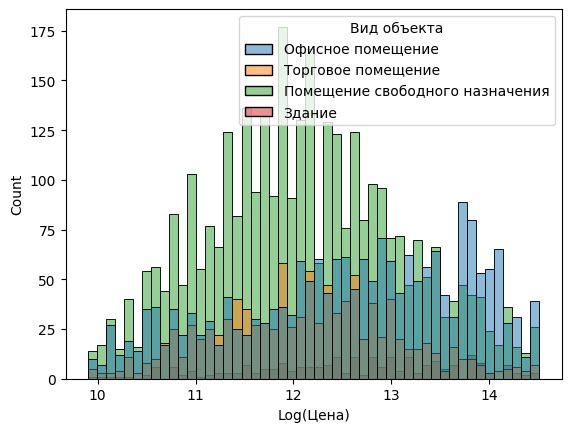

In [43]:
data["Log(Цена)"] = np.log1p(data["Цена"])
sns.histplot(data, x="Log(Цена)",hue="Вид объекта", bins=50)
plt.show()

In [44]:
dfg = data.groupby(by="Вид объекта")["Цена"].mean()
dfg.astype(int)

Вид объекта
Здание                             467013
Офисное помещение                  500771
Помещение свободного назначения    300111
Торговое помещение                 285268
Name: Цена, dtype: int64

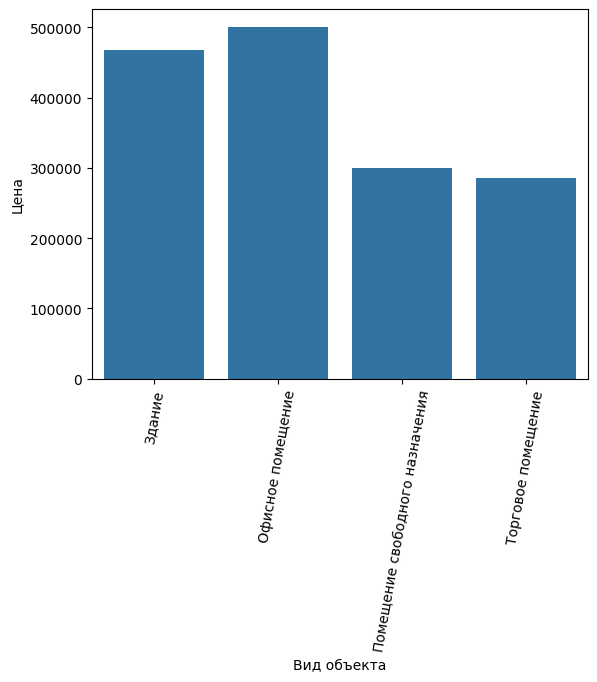

In [45]:
sns.barplot(dfg)
plt.xticks(rotation=80)
plt.show()

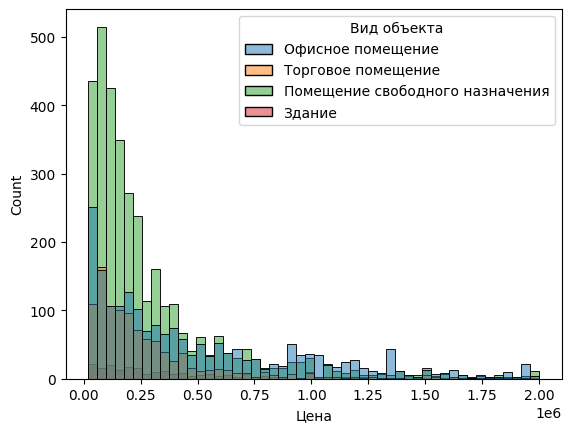

In [46]:
sns.histplot(data, x="Цена",hue="Вид объекта", bins=50)
plt.show()

In [47]:
sns.histplot?

Signature:
sns.histplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    weights=None,
    stat='count',
    bins='auto',
    binwidth=None,
    binrange=None,
    discrete=None,
    cumulative=False,
    common_bins=True,
    common_norm=True,
    multiple='layer',
    element='bars',
    fill=True,
    shrink=1,
    kde=False,
    kde_kws=None,
    line_kws=None,
    thresh=0,
    pthresh=None,
    pmax=None,
    cbar=False,
    cbar_ax=None,
    cbar_kws=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    color=None,
    log_scale=None,
    legend=True,
    ax=None,
    **kwargs,
)
Docstring:
Plot univariate or bivariate histograms to show distributions of datasets.

A histogram is a classic visualization tool that represents the distribution
of one or more variables by counting the number of observations that fall within
discrete bins.

This function can normalize the statistic computed within each bin to estimate
frequency, density or probability mas

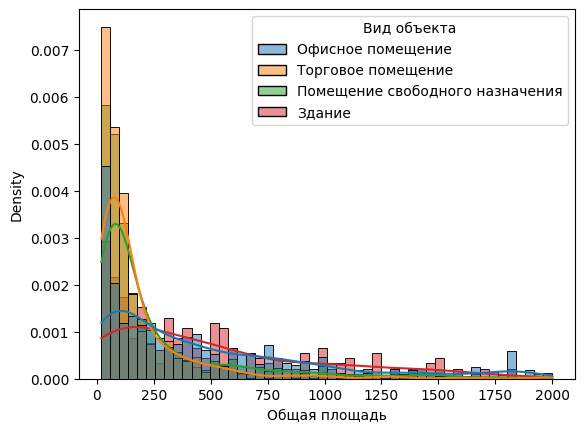

In [48]:
sns.histplot(data, x="Общая площадь",hue="Вид объекта", bins=50, stat="density", common_norm=False, kde=True)
plt.show()

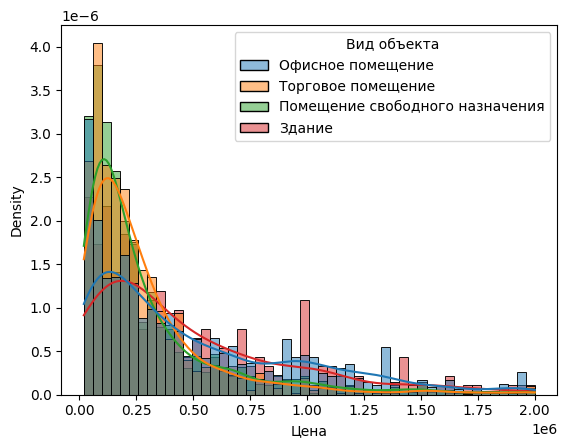

In [49]:
sns.histplot(data, x="Цена",hue="Вид объекта", bins=50, stat="density", common_norm=False, kde=True)
plt.show()

In [50]:
data["Цена / м2"] = data["Цена"] / data["Общая площадь"]
data["Цена / м2"].describe([0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99])

count     6689.000000
mean      1568.534028
std       1207.266137
min         19.444444
1%         128.447455
5%         450.000000
10%        666.666667
20%        881.411765
50%       1375.369128
80%       2083.333763
90%       2683.654896
95%       3045.962733
99%       5000.000000
max      40000.000000
Name: Цена / м2, dtype: float64

In [51]:
data = data[data["Цена / м2"] <= 10000].copy()
data = data[data["Цена / м2"] >= 300].copy()

In [52]:
data.columns

Index(['Цена', 'Дата', 'Тип автора', 'Регион', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Категория', 'Log(Цена)', 'Цена / м2'],
      dtype='object')

In [53]:
data = data.drop(["Регион"], axis=1)

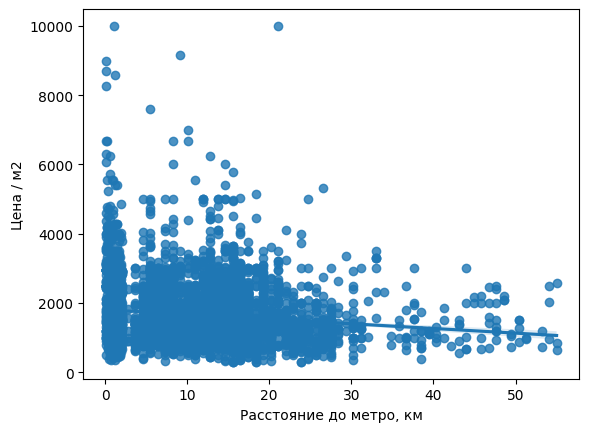

In [54]:
data1 = data.dropna(subset=["Расстояние до метро, км"])
sns.regplot(
    y='Цена / м2', 
    x='Расстояние до метро, км', 
    data=data1)
plt.show()

In [55]:
data["Тип автора"].unique()

array(['Агентство', 'Частное лицо', 'Частное лицо (фильтр)'], dtype=object)

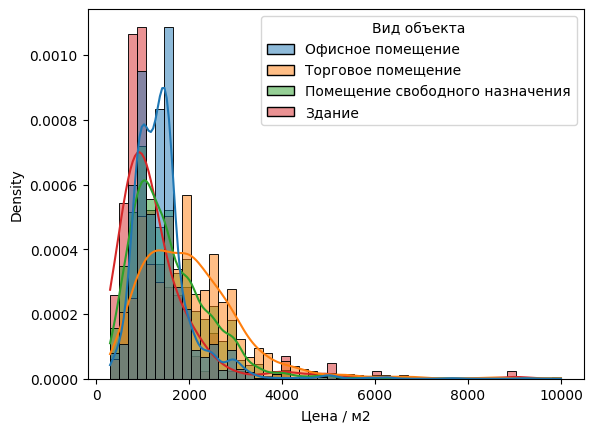

In [56]:
sns.histplot(data, x="Цена / м2",hue="Вид объекта", bins=50, stat="density", common_norm=False, kde=True)
plt.show()

Вид объекта
Здание                             1284.825040
Офисное помещение                  1415.957978
Помещение свободного назначения    1568.846115
Торговое помещение                 2018.787486
Name: Цена / м2, dtype: float64


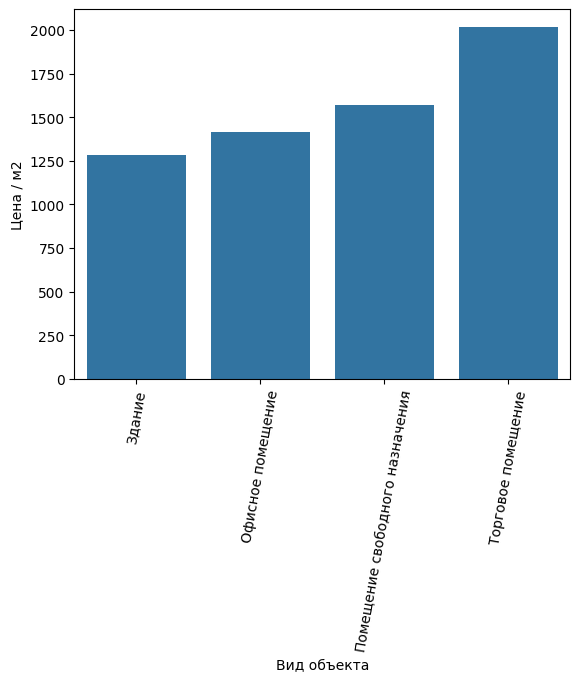

In [57]:
dfg = data.groupby(by="Вид объекта")["Цена / м2"].mean()
dfg.astype(int)
print(dfg)
sns.barplot(dfg)
plt.xticks(rotation=80)
plt.show()

In [58]:
data

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория,Log(Цена),Цена / м2
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офисное помещение,23.0,NaN,10.448744,1500.000000
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое помещение,107.0,NaN,11.986055,1500.000000
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офисное помещение,830.0,NaN,14.019872,1478.000000
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офисное помещение,160.0,NaN,12.373623,1478.000000
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офисное помещение,1040.0,NaN,14.245422,1478.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321236182,cian.ru,220000.0,2025-10-20 00:46:46,Агентство,Химки,Химки,"Куркинское ш., с2","НАЗВАНИЕ: Офис в Московская область, Химки Кур...",55.883439,37.434298,https://www.cian.ru/rent/commercial/321236182,https://images.cdn-cian.ru/images/2609061744-1...,1.917,4.0,29.0,Офисное помещение,100.0,NaN,12.301387,2200.000000
320879786,cian.ru,250000.0,2025-10-19 22:29:12,Агентство,Красногорск,Липовая Роща,"ул. Тенистых Аллей, 1к2",НАЗВАНИЕ: Торговая площадь в Московская област...,55.800580,37.377587,https://www.cian.ru/rent/commercial/320879786,https://images.cdn-cian.ru/images/2597374036-1...,1.000,1.0,31.0,Торговое помещение,45.0,NaN,12.429220,5555.555556
322077443,cian.ru,207000.0,2025-10-19 22:29:12,Агентство,Балашиха,Щёлковская,"ул. Чистопольская, 32",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.843106,37.977258,https://www.cian.ru/rent/commercial/322077443,https://images.cdn-cian.ru/images/2660957824-1...,17.417,1.0,21.0,Помещение свободного назначения,138.0,NaN,12.240479,1500.000000


In [59]:
data["Город"].unique()

array(['Химки', 'Солнечногорск городской округ', 'Мытищи', 'Ступино',
       'Жуковский', 'Люберцы', 'Одинцовский городской округ',
       'Истра муниципальный округ', 'Балашиха', 'Люберцы городской округ',
       'Красногорск', 'Красногорск городской округ', 'Ногинск',
       'Котельники', 'Богородский городской округ', 'Солнечногорск',
       'Видное', 'Подольск', 'Ленинский городской округ',
       'территория Сергиев Посад-6', 'Домодедово городской округ',
       'Долгопрудный', 'Серпухов городской округ', 'Щелково',
       'Павловский Посад', 'Реутов', 'Химки городской округ', 'Одинцово',
       'Подольск городской округ', 'Домодедово',
       'Сергиево-Посадский городской округ', 'Дзержинский', 'Чехов',
       'Волоколамск', 'Пушкинский городской округ',
       'Балашиха городской округ', 'Старая Купавна', 'Электросталь',
       'Мытищи городской округ', 'Раменский муниципальный округ',
       'Орехово-Зуево', 'Королев', 'Лыткарино', 'Клин', 'Электроугли',
       'Раменское', 'Го

In [60]:
data = data.drop("Категория", axis=1)

In [61]:
data

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Log(Цена),Цена / м2
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офисное помещение,23.0,10.448744,1500.000000
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое помещение,107.0,11.986055,1500.000000
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офисное помещение,830.0,14.019872,1478.000000
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офисное помещение,160.0,12.373623,1478.000000
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офисное помещение,1040.0,14.245422,1478.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321236182,cian.ru,220000.0,2025-10-20 00:46:46,Агентство,Химки,Химки,"Куркинское ш., с2","НАЗВАНИЕ: Офис в Московская область, Химки Кур...",55.883439,37.434298,https://www.cian.ru/rent/commercial/321236182,https://images.cdn-cian.ru/images/2609061744-1...,1.917,4.0,29.0,Офисное помещение,100.0,12.301387,2200.000000
320879786,cian.ru,250000.0,2025-10-19 22:29:12,Агентство,Красногорск,Липовая Роща,"ул. Тенистых Аллей, 1к2",НАЗВАНИЕ: Торговая площадь в Московская област...,55.800580,37.377587,https://www.cian.ru/rent/commercial/320879786,https://images.cdn-cian.ru/images/2597374036-1...,1.000,1.0,31.0,Торговое помещение,45.0,12.429220,5555.555556
322077443,cian.ru,207000.0,2025-10-19 22:29:12,Агентство,Балашиха,Щёлковская,"ул. Чистопольская, 32",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.843106,37.977258,https://www.cian.ru/rent/commercial/322077443,https://images.cdn-cian.ru/images/2660957824-1...,17.417,1.0,21.0,Помещение свободного назначения,138.0,12.240479,1500.000000


Этажность здания
0.0     1539.327282
1.0     1456.235658
2.0     1326.269749
3.0     1358.926928
4.0     1426.097633
5.0     1567.390400
6.0     1415.498289
7.0     2024.050108
8.0     1296.870577
9.0     1535.637656
10.0    1934.283683
11.0    2507.330169
12.0    1900.901847
13.0    2154.525460
14.0    1556.282397
15.0    1837.665539
16.0    1936.330571
17.0    1815.399364
18.0    1720.019860
19.0    1612.786317
20.0    1997.547791
21.0    2295.146854
22.0    2044.955872
23.0    1881.047674
24.0    2369.426907
25.0    2145.366883
26.0    2407.139102
27.0    1307.539075
28.0    2550.023540
29.0    1376.773811
30.0    2713.720095
31.0    3675.368145
32.0    2313.697049
33.0    4829.439013
34.0    2730.373516
37.0    2402.870765
41.0    3500.000000
45.0    1314.999581
48.0    1156.697399
57.0    5718.095238
62.0    3591.496063
Name: Цена / м2, dtype: float64


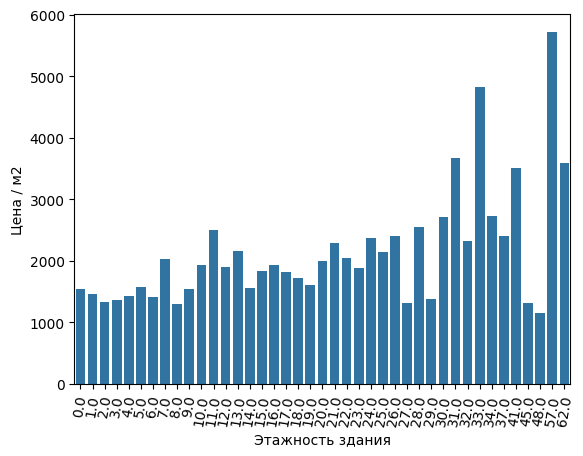

In [62]:
dfg = data.groupby(by="Этажность здания")["Цена / м2"].mean()
dfg.astype(int)
print(dfg)
sns.barplot(dfg)
plt.xticks(rotation=80)
plt.show()

Этаж
-2.0      733.734940
-1.0     1057.395671
 0.0     1255.011259
 1.0     1791.256714
 2.0     1246.738960
 3.0     1220.729682
 4.0     1498.010404
 5.0     1500.864283
 6.0     1313.429588
 7.0     1403.021593
 8.0     1602.301376
 9.0     1497.036427
 10.0    1857.178899
 11.0    1372.492415
 12.0    1078.455741
 13.0    1499.779249
 14.0    1534.738370
 15.0    1376.044407
 16.0    1424.226250
 17.0    1508.189908
 18.0    1024.198921
 19.0    2626.053629
 20.0    1291.669288
 21.0    1316.240527
 22.0    1313.966124
 24.0    1713.121927
 25.0    1481.248663
 26.0    1549.304071
 29.0    1600.000000
 40.0    3500.000000
 45.0    1250.000000
Name: Цена / м2, dtype: float64


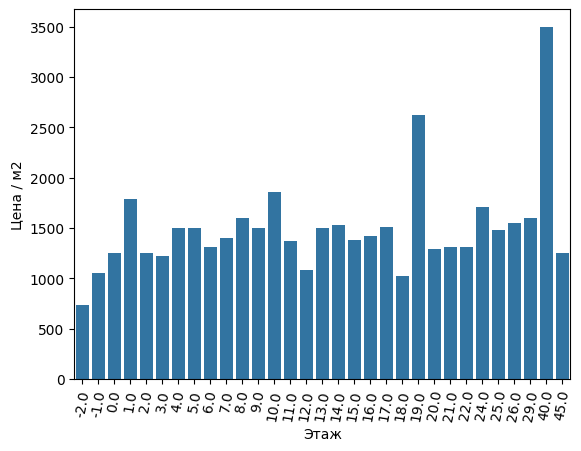

In [63]:
dfg = data.groupby(by="Этаж")["Цена / м2"].mean()
dfg.astype(int)
print(dfg)
sns.barplot(dfg)
plt.xticks(rotation=80)
plt.show()

In [64]:
data = data.drop("Log(Цена)",  axis=1)

In [65]:
data["Вид объекта"] = data["Вид объекта"].replace({'Офисное помещение': 'Офис / Здание', 'Здание': 'Офис / Здание',
                                    'Торговое помещение': 'Торговое / свободного вида',
                                    'Помещение свободного назначения': 'Торговое / свободного вида'})
data["Вид объекта"].unique()

array(['Офис / Здание', 'Торговое / свободного вида'], dtype=object)

In [66]:
data["Тип автора"] = data["Тип автора"].replace({'Частное лицо (фильтр)': 'Частное лицо'})
data["Тип автора"].unique()

array(['Агентство', 'Частное лицо'], dtype=object)

In [70]:
data["Москва?"] = (data["Город"] == "Москва").astype(int)
data["Москва?"].sum()

np.int64(66)

In [71]:
data.to_csv("../data/data_transformed_part1.csv")

In [72]:
data

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.000000,0
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / свободного вида,107.0,1500.000000,0
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.000000,0
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.000000,0
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321236182,cian.ru,220000.0,2025-10-20 00:46:46,Агентство,Химки,Химки,"Куркинское ш., с2","НАЗВАНИЕ: Офис в Московская область, Химки Кур...",55.883439,37.434298,https://www.cian.ru/rent/commercial/321236182,https://images.cdn-cian.ru/images/2609061744-1...,1.917,4.0,29.0,Офис / Здание,100.0,2200.000000,0
320879786,cian.ru,250000.0,2025-10-19 22:29:12,Агентство,Красногорск,Липовая Роща,"ул. Тенистых Аллей, 1к2",НАЗВАНИЕ: Торговая площадь в Московская област...,55.800580,37.377587,https://www.cian.ru/rent/commercial/320879786,https://images.cdn-cian.ru/images/2597374036-1...,1.000,1.0,31.0,Торговое / свободного вида,45.0,5555.555556,0
322077443,cian.ru,207000.0,2025-10-19 22:29:12,Агентство,Балашиха,Щёлковская,"ул. Чистопольская, 32",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.843106,37.977258,https://www.cian.ru/rent/commercial/322077443,https://images.cdn-cian.ru/images/2660957824-1...,17.417,1.0,21.0,Торговое / свободного вида,138.0,1500.000000,0
